In [43]:
# 数据加载和探索性分析

# 导入必要的库
import pandas as pd  # 用于数据处理和分析
import numpy as np  # 用于数值计算
import matplotlib.pyplot as plt  # 用于绘图
import seaborn as sns  # 用于高级统计图表
from sklearn.model_selection import train_test_split  # 用于划分训练集和测试集
from sklearn.linear_model import LinearRegression  # 用于线性回归模型
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # 用于模型评估指标
from mpl_toolkits.mplot3d import Axes3D

# 设置中文显示（避免中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表风格
sns.set_style("whitegrid")

In [44]:
# 数据加载
# 读取CSV文件，index_col=0表示将第一列作为索引列
df = pd.read_csv('Advertising.csv', index_col=0)

print("\n数据集前10行：")
print(df.head(10))

print("\n数据集形状：")
df.shape
# print(f"数据集共有 {df.shape[0]} 行（样本数），{df.shape[1]} 列（特征数+目标变量）")



数据集前10行：
       TV  radio  newspaper  sales
1   230.1   37.8       69.2   22.1
2    44.5   39.3       45.1   10.4
3    17.2   45.9       69.3    9.3
4   151.5   41.3       58.5   18.5
5   180.8   10.8       58.4   12.9
6     8.7   48.9       75.0    7.2
7    57.5   32.8       23.5   11.8
8   120.2   19.6       11.6   13.2
9     8.6    2.1        1.0    4.8
10  199.8    2.6       21.2   10.6

数据集形状：


(200, 4)

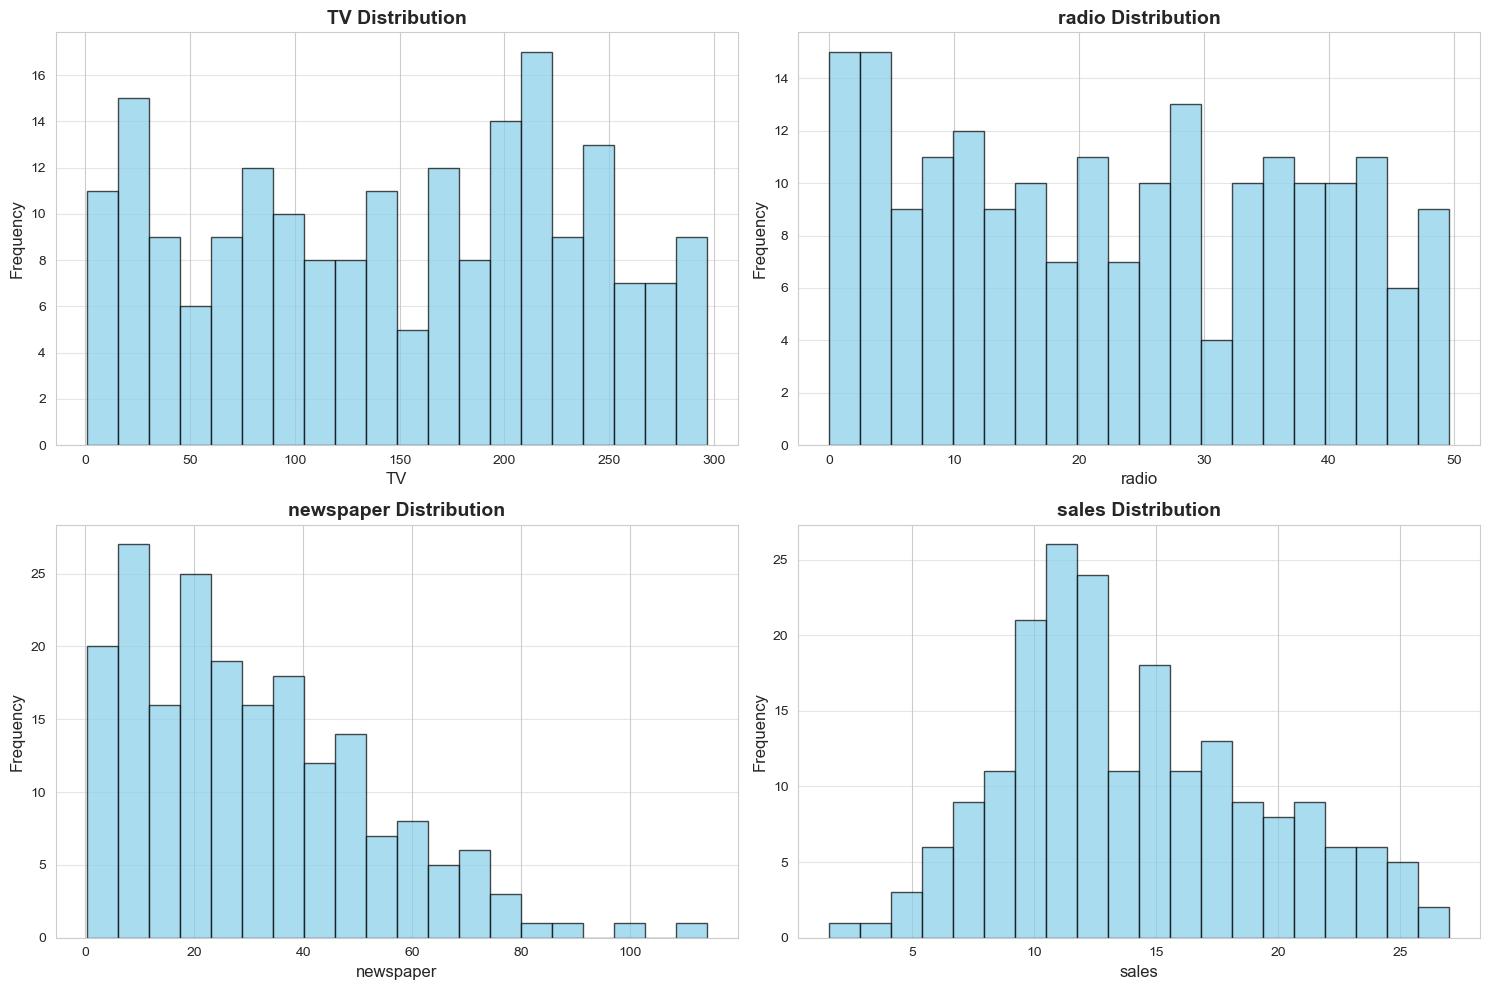

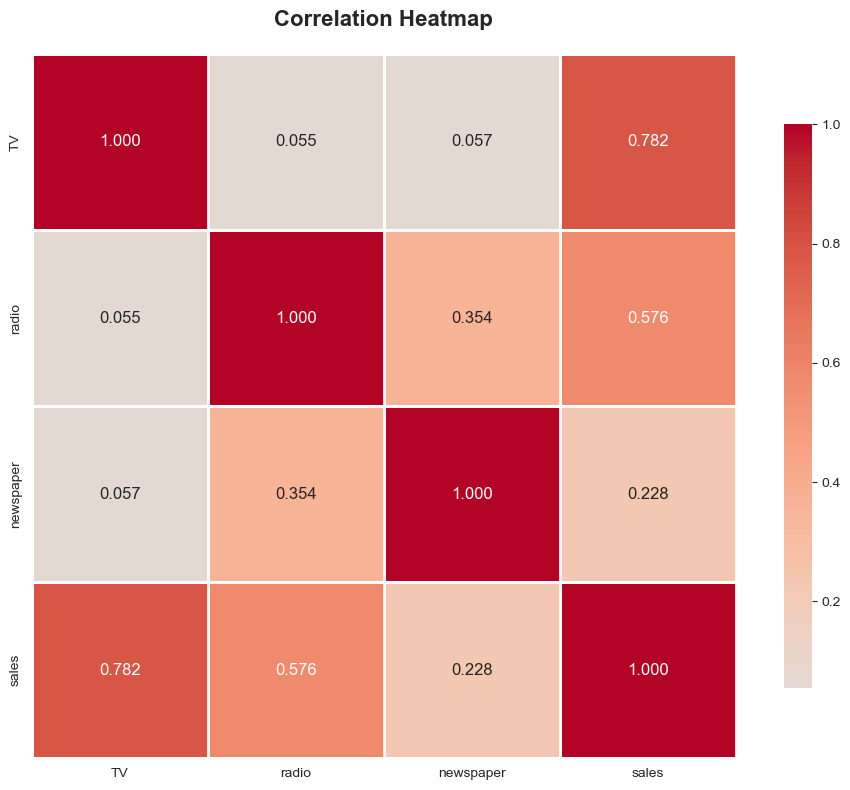

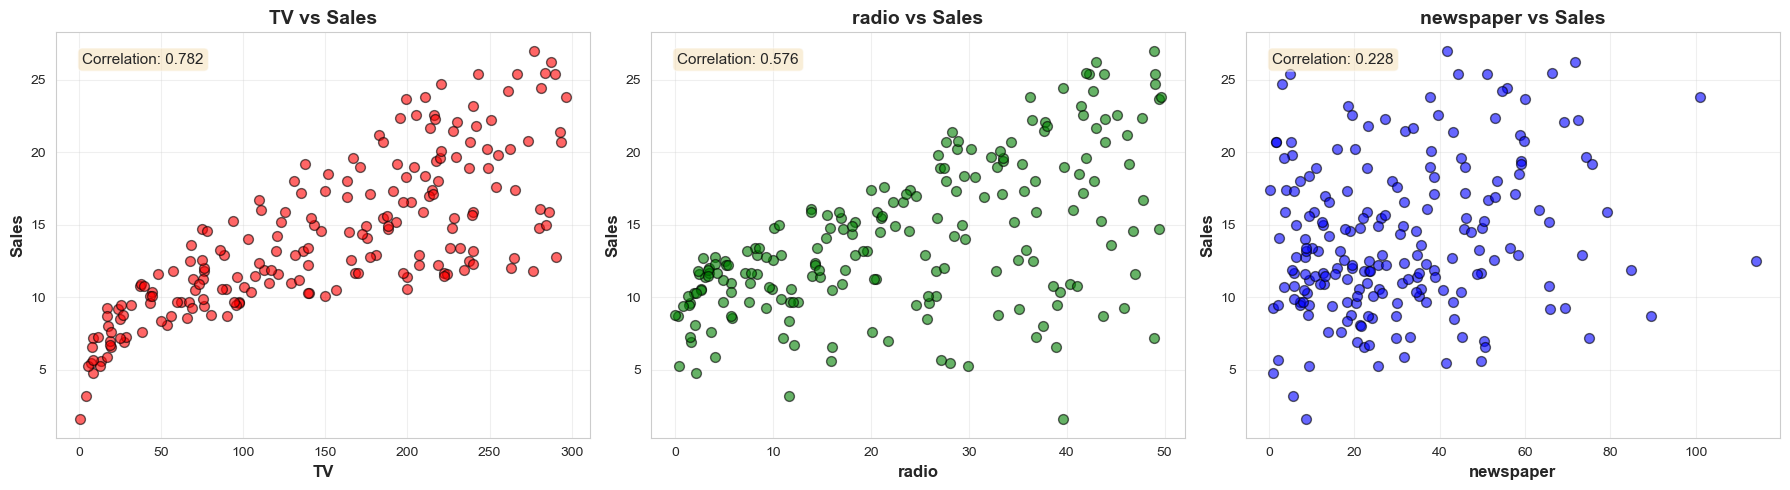

In [45]:
# 数据可视化
correlation_matrix = df.corr()
# 绘制各变量的分布直方图
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[column], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'{column} Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

# 绘制相关系数热力图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', annot_kws={'size': 12})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 绘制每个特征与销售额的散点图（更详细）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['TV', 'radio', 'newspaper']
colors = ['red', 'green', 'blue']

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].scatter(df[feature], df['sales'], alpha=0.6, color=color, edgecolors='black', s=50)
    axes[i].set_xlabel(feature, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Sales', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{feature} vs Sales', fontsize=14, fontweight='bold')
    axes[i].grid(alpha=0.3)
    
    # 计算相关系数并显示在图上
    corr = df[feature].corr(df['sales'])
    axes[i].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                transform=axes[i].transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


一元线性回归：TV -> sales
训练集样本数: 160
测试集样本数: 40

回归方程: sales = 7.1196 + 0.0465 × TV
截距: 7.1196
斜率: 0.0465

训练集评估指标:
  R² Score (决定系数): 0.5912
  MSE (均方误差): 10.6036
  RMSE (均方根误差): 3.2563
  MAE (平均绝对误差): 2.5831

测试集评估指标:
  R² Score (决定系数): 0.6767
  MSE (均方误差): 10.2047
  RMSE (均方根误差): 3.1945
  MAE (平均绝对误差): 2.4444


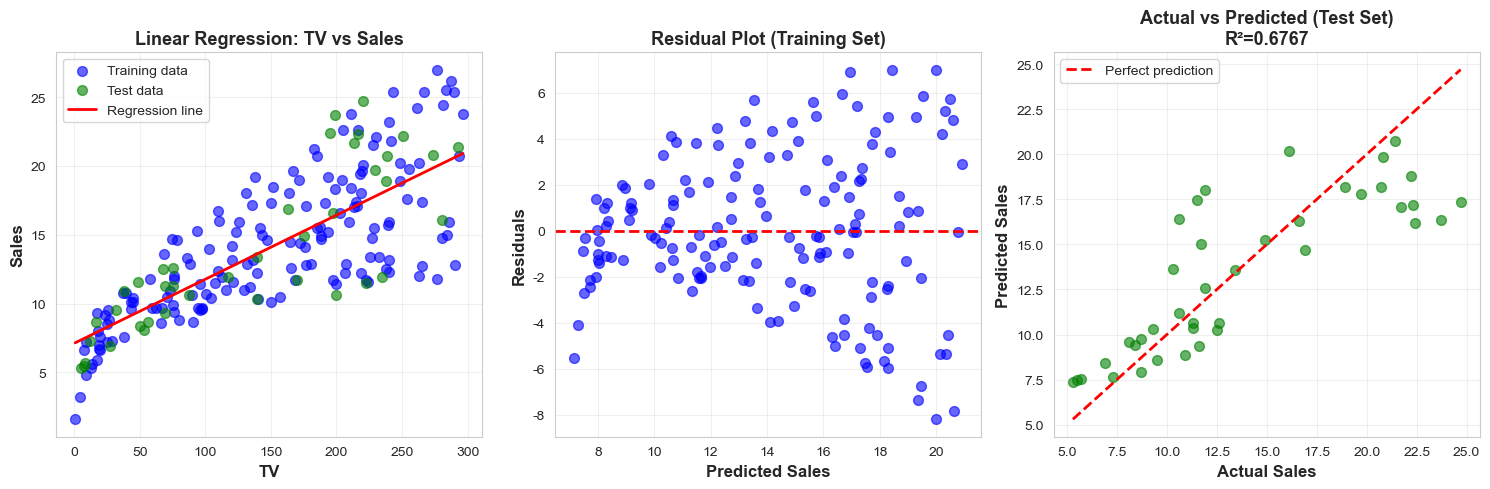


一元线性回归：radio -> sales
训练集样本数: 160
测试集样本数: 40

回归方程: sales = 9.4241 + 0.2044 × radio
截距: 9.4241
斜率: 0.2044

训练集评估指标:
  R² Score (决定系数): 0.3509
  MSE (均方误差): 16.8351
  RMSE (均方根误差): 4.1031
  MAE (平均绝对误差): 3.1433

测试集评估指标:
  R² Score (决定系数): 0.2634
  MSE (均方误差): 23.2488
  RMSE (均方根误差): 4.8217
  MAE (平均绝对误差): 3.9299


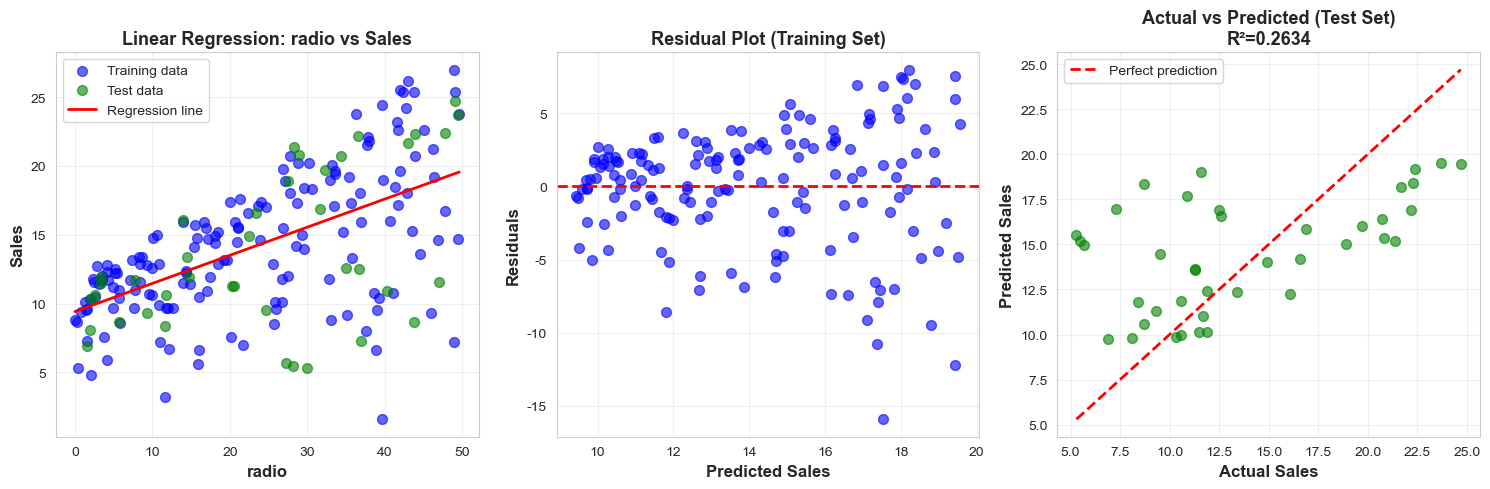


一元线性回归：newspaper -> sales
训练集样本数: 160
测试集样本数: 40

回归方程: sales = 12.3105 + 0.0598 × newspaper
截距: 12.3105
斜率: 0.0598

训练集评估指标:
  R² Score (决定系数): 0.0566
  MSE (均方误差): 24.4687
  RMSE (均方根误差): 4.9466
  MAE (平均绝对误差): 3.9984

测试集评估指标:
  R² Score (决定系数): 0.0299
  MSE (均方误差): 30.6207
  RMSE (均方根误差): 5.5336
  MAE (平均绝对误差): 4.7822


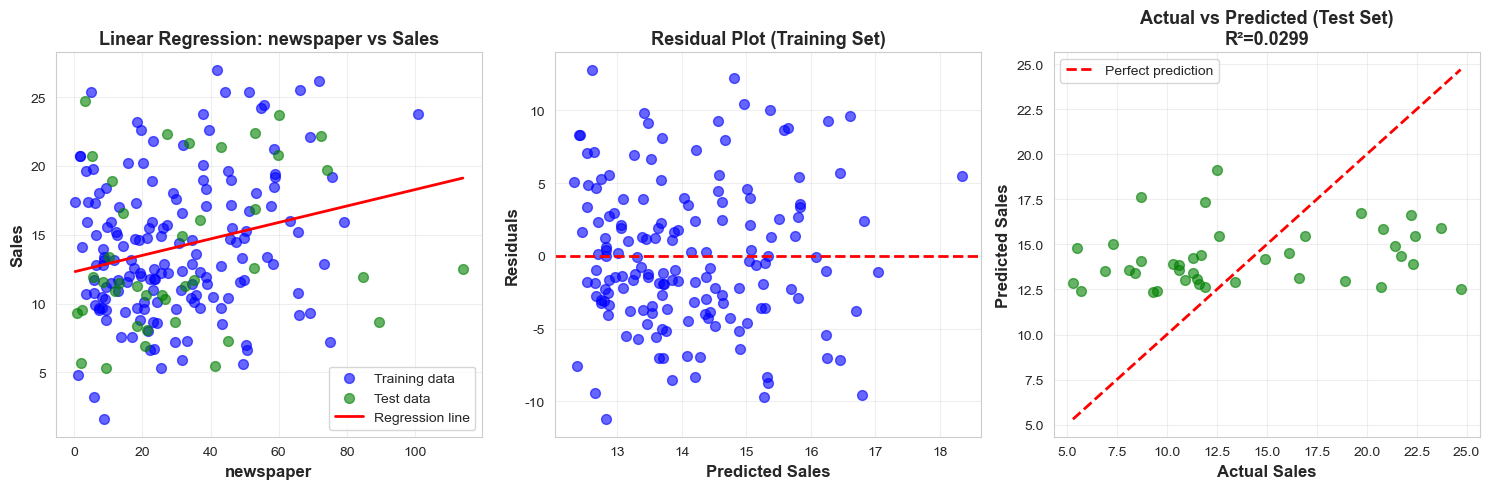


一元线性回归结果汇总
  feature  intercept    slope  train_r2  train_rmse  train_mae  test_r2  test_rmse  test_mae
       TV   7.119638 0.046530  0.591167    3.256317   2.583084 0.676695   3.194472  2.444420
    radio   9.424066 0.204407  0.350906    4.103057   3.143291 0.263431   4.821697  3.929879
newspaper  12.310548 0.059757  0.056584    4.946582   3.998443 0.029872   5.533600  4.782194

一元线性回归结果已保存到 simple_regression_results.csv


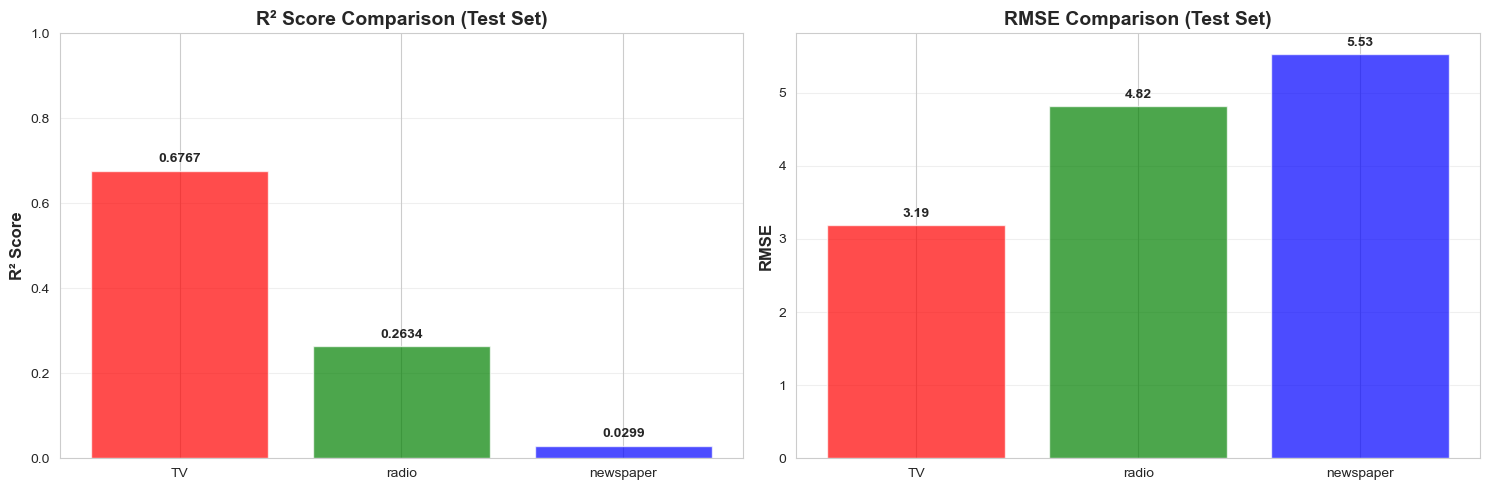

In [46]:
# 一元线性回归分析（分别以TV、radio、newspaper为自变量）
# 定义一个函数来执行一元线性回归并保存结果
def simple_linear_regression(X_name, X_data, y_data, df_original):
    """
    执行一元线性回归分析
    返回包含模型评估指标的字典
    """
    print(f"\n{'=' * 50}")
    print(f"一元线性回归：{X_name} -> sales")
    
    # 将数据转换为二维数组（sklearn要求输入必须是二维的）
    X = X_data.values.reshape(-1, 1)  # reshape(-1, 1)表示转换为n行1列
    y = y_data.values
    
    # 划分训练集和测试集（80%训练，20%测试，random_state用于结果可重复）
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"训练集样本数: {len(X_train)}")
    print(f"测试集样本数: {len(X_test)}")
    
    # 创建并训练线性回归模型
    model = LinearRegression()
    model.fit(X_train, y_train)  # 使用训练集训练模型
    
    # 获取模型参数
    # coef_是斜率（回归系数），intercept_是截距
    slope = model.coef_[0]
    intercept = model.intercept_
    
    print(f"\n回归方程: sales = {intercept:.4f} + {slope:.4f} × {X_name}")
    print(f"截距: {intercept:.4f}")
    print(f"斜率: {slope:.4f}")
    
    # 使用模型进行预测
    y_train_pred = model.predict(X_train)  # 训练集预测
    y_test_pred = model.predict(X_test)    # 测试集预测
    
    # 计算训练集的评估指标
    train_mse = mean_squared_error(y_train, y_train_pred)  # 均方误差
    train_rmse = np.sqrt(train_mse)  # 均方根误差
    train_mae = mean_absolute_error(y_train, y_train_pred)  # 平均绝对误差
    train_r2 = r2_score(y_train, y_train_pred)  # R²决定系数
    
    # 计算测试集的评估指标
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n训练集评估指标:")
    print(f"  R² Score (决定系数): {train_r2:.4f}")
    print(f"  MSE (均方误差): {train_mse:.4f}")
    print(f"  RMSE (均方根误差): {train_rmse:.4f}")
    print(f"  MAE (平均绝对误差): {train_mae:.4f}")
    
    print(f"\n测试集评估指标:")
    print(f"  R² Score (决定系数): {test_r2:.4f}")
    print(f"  MSE (均方误差): {test_mse:.4f}")
    print(f"  RMSE (均方根误差): {test_rmse:.4f}")
    print(f"  MAE (平均绝对误差): {test_mae:.4f}")
    
    # 绘制回归图
    plt.figure(figsize=(15, 5))
    
    # 子图1: 散点图 + 回归线
    plt.subplot(1, 3, 1)
    plt.scatter(X_train, y_train, alpha=0.6, color='blue', label='Training data', s=50)
    plt.scatter(X_test, y_test, alpha=0.6, color='green', label='Test data', s=50)
    
    # 绘制回归线（使用整个数据范围）
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_range_pred = model.predict(X_range)
    plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Regression line')
    
    plt.xlabel(X_name, fontsize=12, fontweight='bold')
    plt.ylabel('Sales', fontsize=12, fontweight='bold')
    plt.title(f'Linear Regression: {X_name} vs Sales', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 子图2: 残差图（训练集）
    plt.subplot(1, 3, 2)
    residuals_train = y_train - y_train_pred
    plt.scatter(y_train_pred, residuals_train, alpha=0.6, color='blue', s=50)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Predicted Sales', fontsize=12, fontweight='bold')
    plt.ylabel('Residuals', fontsize=12, fontweight='bold')
    plt.title('Residual Plot (Training Set)', fontsize=13, fontweight='bold')
    plt.grid(alpha=0.3)
    
    # 子图3: 预测值vs实际值（测试集）
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.6, color='green', s=50)
    # 绘制理想预测线（y=x）
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    plt.xlabel('Actual Sales', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted Sales', fontsize=12, fontweight='bold')
    plt.title(f'Actual vs Predicted (Test Set)\nR²={test_r2:.4f}', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 返回评估指标字典
    return {
        'feature': X_name,
        'intercept': intercept,
        'slope': slope,
        'train_r2': train_r2,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    }

# 对三个特征分别进行一元线性回归
features = ['TV', 'radio', 'newspaper']
results_simple = []

for feature in features:
    result = simple_linear_regression(feature, df[feature], df['sales'], df)
    results_simple.append(result)

# 汇总一元线性回归结果
print("\n" + "=" * 60)
print("一元线性回归结果汇总")

results_df = pd.DataFrame(results_simple)
print(results_df.to_string(index=False))

# 保存结果到CSV
results_df.to_csv('simple_regression_results.csv', index=False)
print("\n一元线性回归结果已保存到 simple_regression_results.csv")

# 绘制对比图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 子图1: R²对比
axes[0].bar(results_df['feature'], results_df['test_r2'], color=['red', 'green', 'blue'], alpha=0.7)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['test_r2']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 子图2: RMSE对比
axes[1].bar(results_df['feature'], results_df['test_rmse'], color=['red', 'green', 'blue'], alpha=0.7)
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['test_rmse']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
# 多元线性回归分析（使用所有特征）

# 准备特征矩阵X和目标变量y
# X包含所有自变量（TV, radio, newspaper）
# y是因变量（sales）
X = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values

print(f"特征矩阵 X 的形状: {X.shape}")
print(f"目标变量 y 的形状: {y.shape}")

# 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")

# 创建并训练多元线性回归模型
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# 获取模型参数
# coef_是各个特征的回归系数（斜率）
# intercept_是截距
coefficients = multi_model.coef_
intercept = multi_model.intercept_

print("=" * 50)
print("多元线性回归方程:")
print(f"sales = {intercept:.4f} + {coefficients[0]:.4f}×TV + {coefficients[1]:.4f}×radio + {coefficients[2]:.4f}×newspaper")
print(f"截距 (intercept): {intercept:.4f}")
print(f"TV 系数: {coefficients[0]:.4f}")
print(f"radio 系数: {coefficients[1]:.4f}")
print(f"newspaper 系数: {coefficients[2]:.4f}")

# 使用模型进行预测
y_train_pred = multi_model.predict(X_train)
y_test_pred = multi_model.predict(X_test)

# 计算训练集的评估指标
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# 计算测试集的评估指标
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 50)
print("训练集评估指标:")
print(f"R² Score (决定系数): {train_r2:.4f}")
print(f"MSE (均方误差): {train_mse:.4f}")
print(f"RMSE (均方根误差): {train_rmse:.4f}")
print(f"MAE (平均绝对误差): {train_mae:.4f}")

print("=" * 50)
print("测试集评估指标:")
print(f"R² Score (决定系数): {test_r2:.4f}")
print(f"MSE (均方误差): {test_mse:.4f}")
print(f"RMSE (均方根误差): {test_rmse:.4f}")
print(f"MAE (平均绝对误差): {test_mae:.4f}")

# 计算调整R²（Adjusted R²）
# 调整R²考虑了特征数量，避免过拟合
n = len(y_train)  # 样本数
p = X_train.shape[1]  # 特征数
adjusted_r2_train = 1 - (1 - train_r2) * (n - 1) / (n - p - 1)

n_test = len(y_test)
adjusted_r2_test = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)

print(f"\nAdjusted R² (训练集): {adjusted_r2_train:.4f}")
print(f"Adjusted R² (测试集): {adjusted_r2_test:.4f}")

# 创建系数DataFrame用于分析
coef_df = pd.DataFrame({
    'Feature': ['TV', 'radio', 'newspaper'],
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("=" * 50)
print("特征重要性（按系数绝对值排序）:")
print(coef_df.to_string(index=False))

# 保存多元回归结果
multi_results = {
    'Model': 'Multiple Linear Regression',
    'Features': 'TV + radio + newspaper',
    'Intercept': intercept,
    'TV_coef': coefficients[0],
    'radio_coef': coefficients[1],
    'newspaper_coef': coefficients[2],
    'Train_R2': train_r2,
    'Train_Adjusted_R2': adjusted_r2_train,
    'Train_RMSE': train_rmse,
    'Train_MAE': train_mae,
    'Test_R2': test_r2,
    'Test_Adjusted_R2': adjusted_r2_test,
    'Test_RMSE': test_rmse,
    'Test_MAE': test_mae
}

multi_results_df = pd.DataFrame([multi_results])
multi_results_df.to_csv('multiple_regression_results.csv', index=False)
print("\n多元回归结果已保存到 multiple_regression_results.csv")

特征矩阵 X 的形状: (200, 3)
目标变量 y 的形状: (200,)

训练集样本数: 160
测试集样本数: 40
多元线性回归方程:
sales = 2.9791 + 0.0447×TV + 0.1892×radio + 0.0028×newspaper
截距 (intercept): 2.9791
TV 系数: 0.0447
radio 系数: 0.1892
newspaper 系数: 0.0028
训练集评估指标:
R² Score (决定系数): 0.8957
MSE (均方误差): 2.7051
RMSE (均方根误差): 1.6447
MAE (平均绝对误差): 1.1985
测试集评估指标:
R² Score (决定系数): 0.8994
MSE (均方误差): 3.1741
RMSE (均方根误差): 1.7816
MAE (平均绝对误差): 1.4608

Adjusted R² (训练集): 0.8937
Adjusted R² (测试集): 0.8911
特征重要性（按系数绝对值排序）:
  Feature  Coefficient  Abs_Coefficient
    radio     0.189195         0.189195
       TV     0.044730         0.044730
newspaper     0.002761         0.002761

多元回归结果已保存到 multiple_regression_results.csv


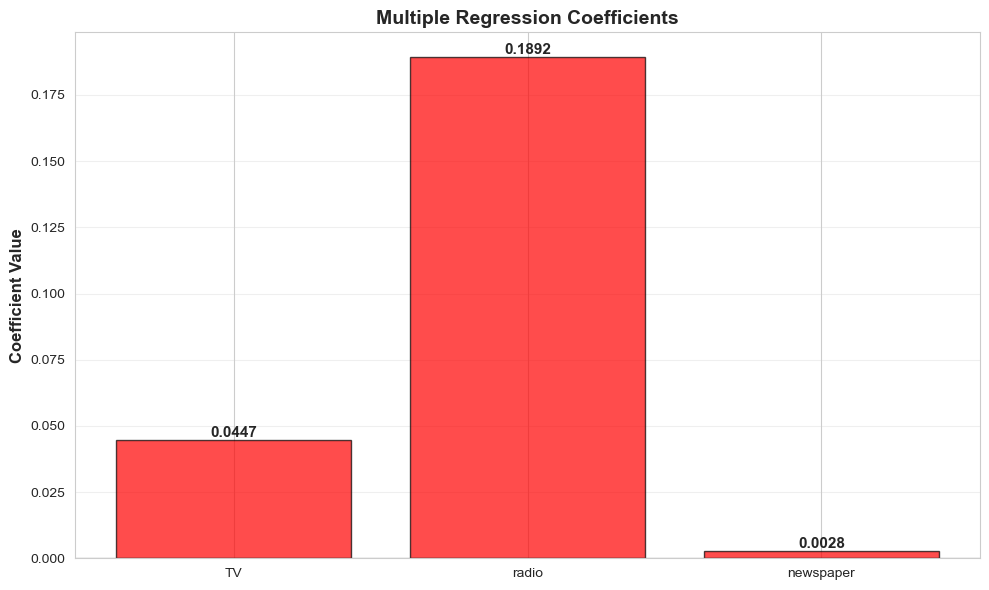

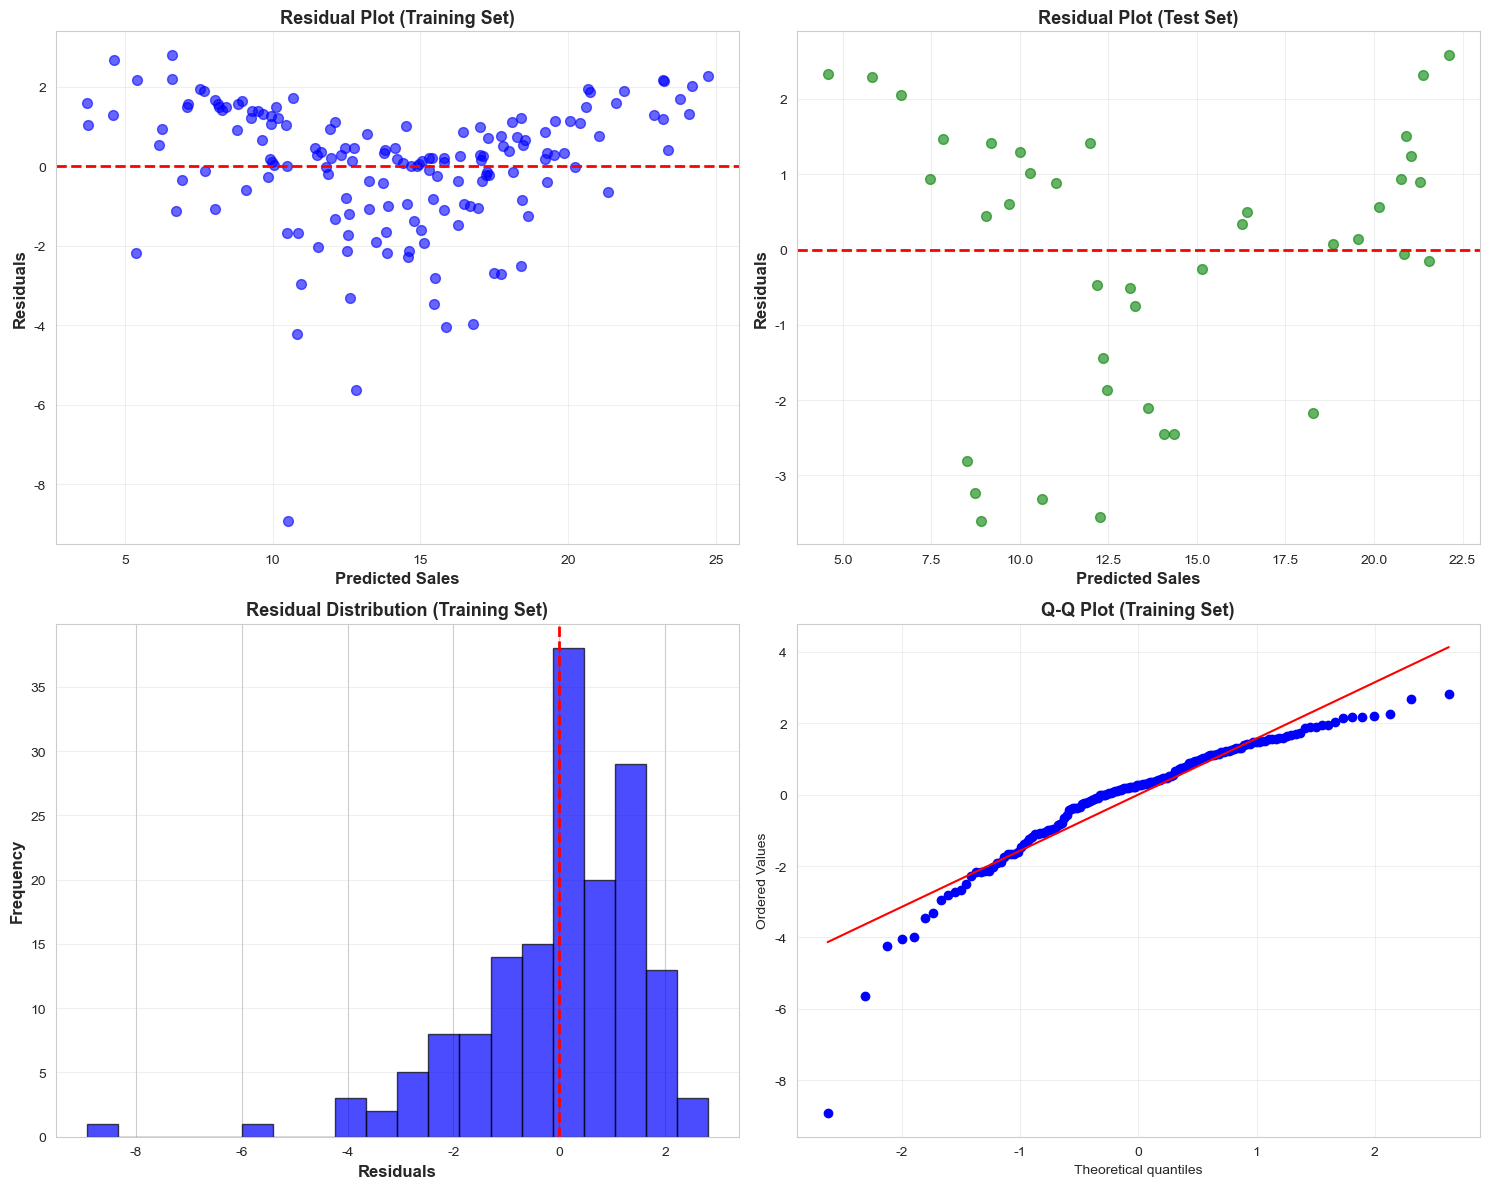

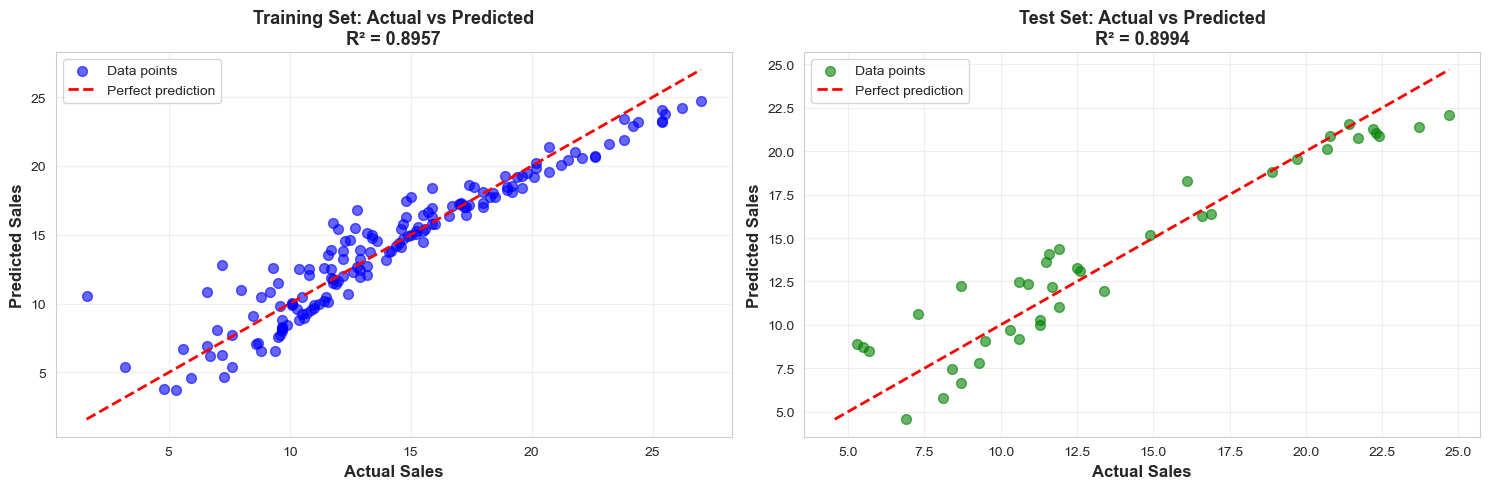

In [48]:
# 多元回归可视化
# 系数条形图
plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'blue' for c in coefficients]
bars = plt.bar(['TV', 'radio', 'newspaper'], coefficients, color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.ylabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.title('Multiple Regression Coefficients', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# 在条形图上标注数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 残差分析图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 子图1: 残差vs预测值（训练集）
residuals_train = y_train - y_train_pred
axes[0, 0].scatter(y_train_pred, residuals_train, alpha=0.6, color='blue', s=50)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Sales', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Residual Plot (Training Set)', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 子图2: 残差vs预测值（测试集）
residuals_test = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals_test, alpha=0.6, color='green', s=50)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Sales', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Residual Plot (Test Set)', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 子图3: 残差直方图（训练集）
axes[1, 0].hist(residuals_train, bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Residual Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].grid(axis='y', alpha=0.3)

# 子图4: Q-Q图（检验残差正态性）
from scipy import stats
stats.probplot(residuals_train, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Training Set)', fontsize=13, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 预测值vs实际值对比图
plt.figure(figsize=(15, 5))
# 训练集
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=50, label='Data points')
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Sales', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Sales', fontsize=12, fontweight='bold')
plt.title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 测试集
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='green', s=50, label='Data points')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Sales', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Sales', fontsize=12, fontweight='bold')
plt.title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# 一元回归和多元回归的完整对比
# 重新运行所有模型以获取完整对比数据
X_full = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values

# 划分数据集
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

# 存储所有模型的结果
all_models_results = []

# TV单独预测
X_train_tv = X_train_full[:, 0].reshape(-1, 1)
X_test_tv = X_test_full[:, 0].reshape(-1, 1)
model_tv = LinearRegression()
model_tv.fit(X_train_tv, y_train)
y_pred_tv = model_tv.predict(X_test_tv)
r2_tv = r2_score(y_test, y_pred_tv)
rmse_tv = np.sqrt(mean_squared_error(y_test, y_pred_tv))
mae_tv = mean_absolute_error(y_test, y_pred_tv)
all_models_results.append({
    'Model': 'TV Only',
    'Features': 'TV',
    'R2': r2_tv,
    'RMSE': rmse_tv,
    'MAE': mae_tv
})

In [50]:
# 2. radio单独预测
X_train_radio = X_train_full[:, 1].reshape(-1, 1)
X_test_radio = X_test_full[:, 1].reshape(-1, 1)
model_radio = LinearRegression()
model_radio.fit(X_train_radio, y_train)
y_pred_radio = model_radio.predict(X_test_radio)
r2_radio = r2_score(y_test, y_pred_radio)
rmse_radio = np.sqrt(mean_squared_error(y_test, y_pred_radio))
mae_radio = mean_absolute_error(y_test, y_pred_radio)
all_models_results.append({
    'Model': 'radio Only',
    'Features': 'radio',
    'R2': r2_radio,
    'RMSE': rmse_radio,
    'MAE': mae_radio
})


In [51]:
# 3. newspaper单独预测
X_train_newspaper = X_train_full[:, 2].reshape(-1, 1)
X_test_newspaper = X_test_full[:, 2].reshape(-1, 1)
model_newspaper = LinearRegression()
model_newspaper.fit(X_train_newspaper, y_train)
y_pred_newspaper = model_newspaper.predict(X_test_newspaper)
r2_newspaper = r2_score(y_test, y_pred_newspaper)
rmse_newspaper = np.sqrt(mean_squared_error(y_test, y_pred_newspaper))
mae_newspaper = mean_absolute_error(y_test, y_pred_newspaper)
all_models_results.append({
    'Model': 'newspaper Only',
    'Features': 'newspaper',
    'R2': r2_newspaper,
    'RMSE': rmse_newspaper,
    'MAE': mae_newspaper
})

In [52]:
# 4. TV + radio（双变量）
X_train_tv_radio = X_train_full[:, [0, 1]]
X_test_tv_radio = X_test_full[:, [0, 1]]
model_tv_radio = LinearRegression()
model_tv_radio.fit(X_train_tv_radio, y_train)
y_pred_tv_radio = model_tv_radio.predict(X_test_tv_radio)
r2_tv_radio = r2_score(y_test, y_pred_tv_radio)
rmse_tv_radio = np.sqrt(mean_squared_error(y_test, y_pred_tv_radio))
mae_tv_radio = mean_absolute_error(y_test, y_pred_tv_radio)
all_models_results.append({
    'Model': 'TV + radio',
    'Features': 'TV, radio',
    'R2': r2_tv_radio,
    'RMSE': rmse_tv_radio,
    'MAE': mae_tv_radio
})

In [53]:
# 5. TV + newspaper（双变量）
X_train_tv_news = X_train_full[:, [0, 2]]
X_test_tv_news = X_test_full[:, [0, 2]]
model_tv_news = LinearRegression()
model_tv_news.fit(X_train_tv_news, y_train)
y_pred_tv_news = model_tv_news.predict(X_test_tv_news)
r2_tv_news = r2_score(y_test, y_pred_tv_news)
rmse_tv_news = np.sqrt(mean_squared_error(y_test, y_pred_tv_news))
mae_tv_news = mean_absolute_error(y_test, y_pred_tv_news)
all_models_results.append({
    'Model': 'TV + newspaper',
    'Features': 'TV, newspaper',
    'R2': r2_tv_news,
    'RMSE': rmse_tv_news,
    'MAE': mae_tv_news
})


In [54]:
# 6. radio + newspaper（双变量）
X_train_radio_news = X_train_full[:, [1, 2]]
X_test_radio_news = X_test_full[:, [1, 2]]
model_radio_news = LinearRegression()
model_radio_news.fit(X_train_radio_news, y_train)
y_pred_radio_news = model_radio_news.predict(X_test_radio_news)
r2_radio_news = r2_score(y_test, y_pred_radio_news)
rmse_radio_news = np.sqrt(mean_squared_error(y_test, y_pred_radio_news))
mae_radio_news = mean_absolute_error(y_test, y_pred_radio_news)
all_models_results.append({
    'Model': 'radio + newspaper',
    'Features': 'radio, newspaper',
    'R2': r2_radio_news,
    'RMSE': rmse_radio_news,
    'MAE': mae_radio_news
})

In [55]:
# 7. 所有特征（多元回归）
model_all = LinearRegression()
model_all.fit(X_train_full, y_train)
y_pred_all = model_all.predict(X_test_full)
r2_all = r2_score(y_test, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
mae_all = mean_absolute_error(y_test, y_pred_all)
all_models_results.append({
    'Model': 'All Features',
    'Features': 'TV, radio, newspaper',
    'R2': r2_all,
    'RMSE': rmse_all,
    'MAE': mae_all
})

In [56]:
# 创建对比表格
comparison_df = pd.DataFrame(all_models_results)
comparison_df = comparison_df.sort_values('R2', ascending=False)

print("\n所有模型性能对比（按R²排序）：")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# 保存对比结果
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n模型对比结果已保存到 model_comparison_results.csv")


所有模型性能对比（按R²排序）：
            Model             Features       R2     RMSE      MAE
       TV + radio            TV, radio 0.900583 1.771425 1.444302
     All Features TV, radio, newspaper 0.899438 1.781600 1.460757
          TV Only                   TV 0.676695 3.194472 2.444420
   TV + newspaper        TV, newspaper 0.649515 3.326042 2.459443
radio + newspaper     radio, newspaper 0.264829 4.817120 3.922130
       radio Only                radio 0.263431 4.821697 3.929879
   newspaper Only            newspaper 0.029872 5.533600 4.782194

模型对比结果已保存到 model_comparison_results.csv


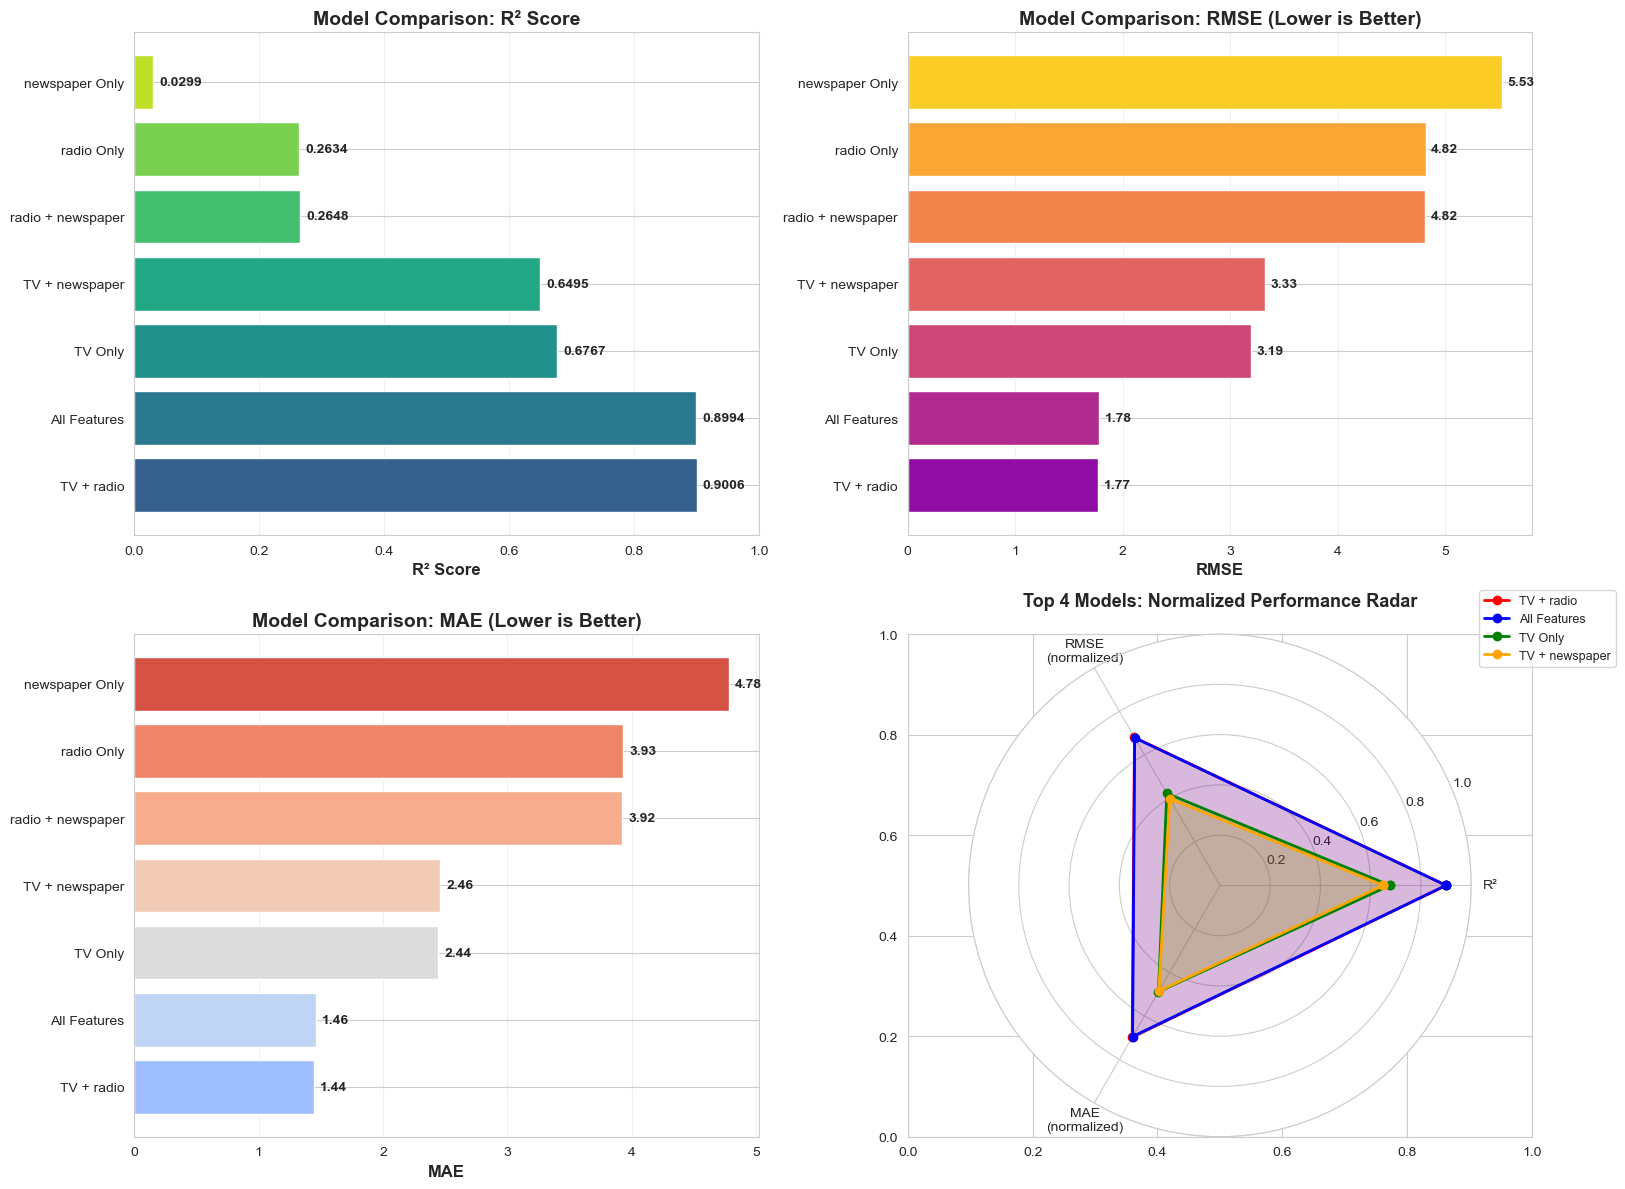

In [57]:
# 综合可视化对比
# 创建综合对比图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 子图1: R²对比
ax1 = axes[0, 0]
bars1 = ax1.barh(comparison_df['Model'], comparison_df['R2'], 
                 color=plt.cm.viridis(np.linspace(0.3, 0.9, len(comparison_df))))
ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: R² Score', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
ax1.grid(axis='x', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars1, comparison_df['R2'])):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', va='center', fontweight='bold', fontsize=10)
# 子图2: RMSE对比
ax2 = axes[0, 1]
bars2 = ax2.barh(comparison_df['Model'], comparison_df['RMSE'], 
                 color=plt.cm.plasma(np.linspace(0.3, 0.9, len(comparison_df))))
ax2.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('Model Comparison: RMSE (Lower is Better)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars2, comparison_df['RMSE'])):
    ax2.text(value + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{value:.2f}', va='center', fontweight='bold', fontsize=10)
# 子图3: MAE对比
ax3 = axes[1, 0]
bars3 = ax3.barh(comparison_df['Model'], comparison_df['MAE'], 
                 color=plt.cm.coolwarm(np.linspace(0.3, 0.9, len(comparison_df))))
ax3.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('Model Comparison: MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars3, comparison_df['MAE'])):
    ax3.text(value + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{value:.2f}', va='center', fontweight='bold', fontsize=10)

# 子图4: 综合性能雷达图（归一化后的指标）
ax4 = axes[1, 1]
# 选择前4个最佳模型进行雷达图对比
top_models = comparison_df.head(4)

# 归一化指标（R²越大越好，RMSE和MAE越小越好）
# 对于R²，直接使用
# 对于RMSE和MAE，使用1-归一化值
max_rmse = comparison_df['RMSE'].max()
max_mae = comparison_df['MAE'].max()

angles = np.linspace(0, 2 * np.pi, 3, endpoint=False).tolist()
angles += angles[:1]  # 闭合雷达图

ax4 = plt.subplot(2, 2, 4, projection='polar')
colors_radar = ['red', 'blue', 'green', 'orange']

for idx, (i, row) in enumerate(top_models.iterrows()):
    values = [
        row['R2'],
        1 - row['RMSE'] / max_rmse,  # 转换为越大越好
        1 - row['MAE'] / max_mae     # 转换为越大越好
    ]
    values += values[:1]  # 闭合
    ax4.plot(angles, values, 'o-', linewidth=2, label=row['Model'], 
            color=colors_radar[idx], markersize=6)
    ax4.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(['R²', 'RMSE\n(normalized)', 'MAE\n(normalized)'], fontsize=10)
ax4.set_ylim(0, 1)
ax4.set_title('Top 4 Models: Normalized Performance Radar', 
             fontsize=13, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax4.grid(True)

plt.tight_layout()
plt.show()


特征重要性排序：
  Feature  Coefficient  Abs_Coefficient  Importance_Percentage
    radio     0.189195         0.189195              79.935148
       TV     0.044730         0.044730              18.898277
newspaper     0.002761         0.002761               1.166574


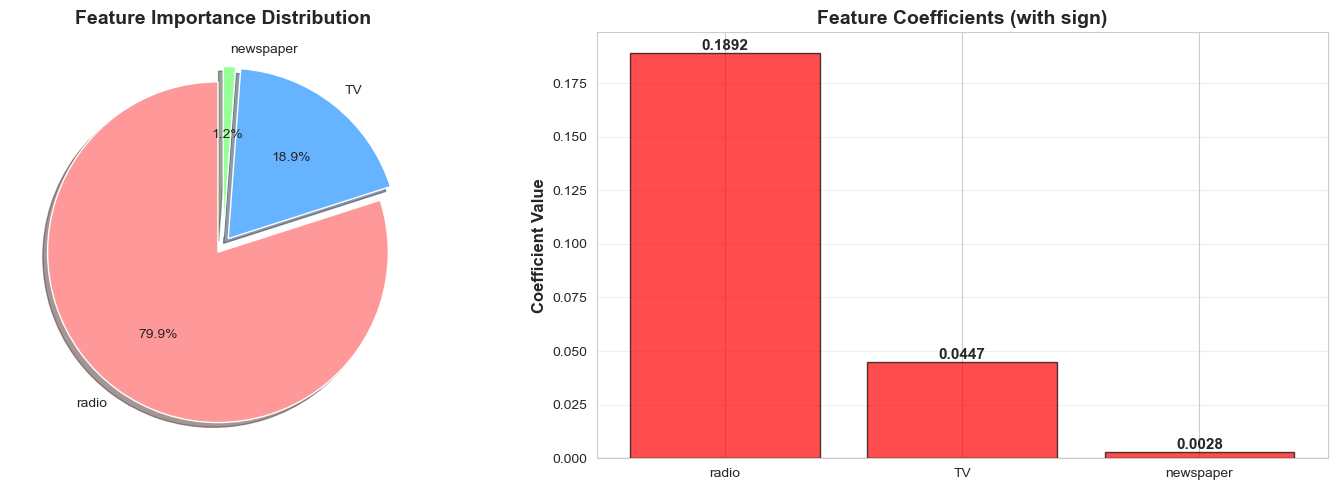

In [58]:
# 特征重要性分析（基于最佳多元模型）
# 使用所有特征的模型
coefficients_all = model_all.coef_
feature_importance = pd.DataFrame({
    'Feature': ['TV', 'radio', 'newspaper'],
    'Coefficient': coefficients_all,
    'Abs_Coefficient': np.abs(coefficients_all),
    'Importance_Percentage': np.abs(coefficients_all) / np.sum(np.abs(coefficients_all)) * 100
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\n特征重要性排序：")
print(feature_importance.to_string(index=False))

# 绘制特征重要性图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 饼图
axes[0].pie(feature_importance['Importance_Percentage'], 
           labels=feature_importance['Feature'],
           autopct='%1.1f%%',
           startangle=90,
           colors=['#ff9999', '#66b3ff', '#99ff99'],
           explode=(0.05, 0.05, 0.05),
           shadow=True)
axes[0].set_title('Feature Importance Distribution', fontsize=14, fontweight='bold')

# 条形图（显示系数正负）
colors_bar = ['red' if c > 0 else 'blue' for c in feature_importance['Coefficient']]
bars = axes[1].bar(feature_importance['Feature'], feature_importance['Coefficient'], 
                   color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Coefficients (with sign)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()